In [138]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [2]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered["label"].value_counts())



label
0    18399879
1      100118
Name: count, dtype: int64


In [3]:
logsum_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_logsum/pileup.npz"
with np.load(logsum_df, allow_pickle=True) as data:
    logsum_df = pd.DataFrame({key: data[key] for key in data.keys()})
logsum_df = logsum_df[logsum_df["count_dom"] >= 20]
logsum_df = logsum_df.merge(label_df_filtered, on="label_id", how="inner")
print(logsum_df)

                label_id  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000      0.000000        0.000000          0   
1         NM_000016:1008      0.000000        0.000000          0   
2         NM_000016:1009      0.000000        0.000000          0   
3         NM_000016:1010      0.000000        0.000000          0   
4         NM_000016:1014      0.000000        0.000000          0   
...                  ...           ...             ...        ...   
10794116  NR_182669:3964      0.000000        0.000000          0   
10794117  NR_182669:3965      0.000000        0.000000          0   
10794118  NR_182669:3966      0.000000        0.000000          0   
10794119  NR_182669:3968     -0.006871       -1.804221          1   
10794120  NR_182669:3969      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg  count_neg  logsum_p_all  \
0          -956.270630       -0.051888        255   -958.656189   
1          -889.857605       -0.16393

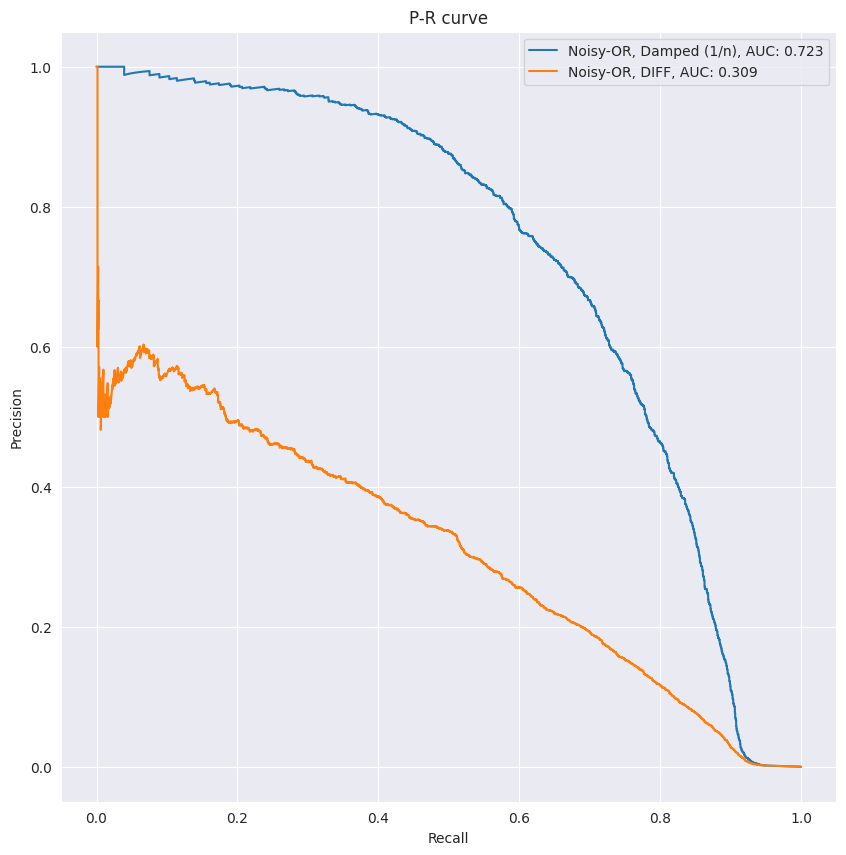

In [7]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff"] = - selected_df["logsum_1_p_pos"] + selected_df["logsum_p_pos"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


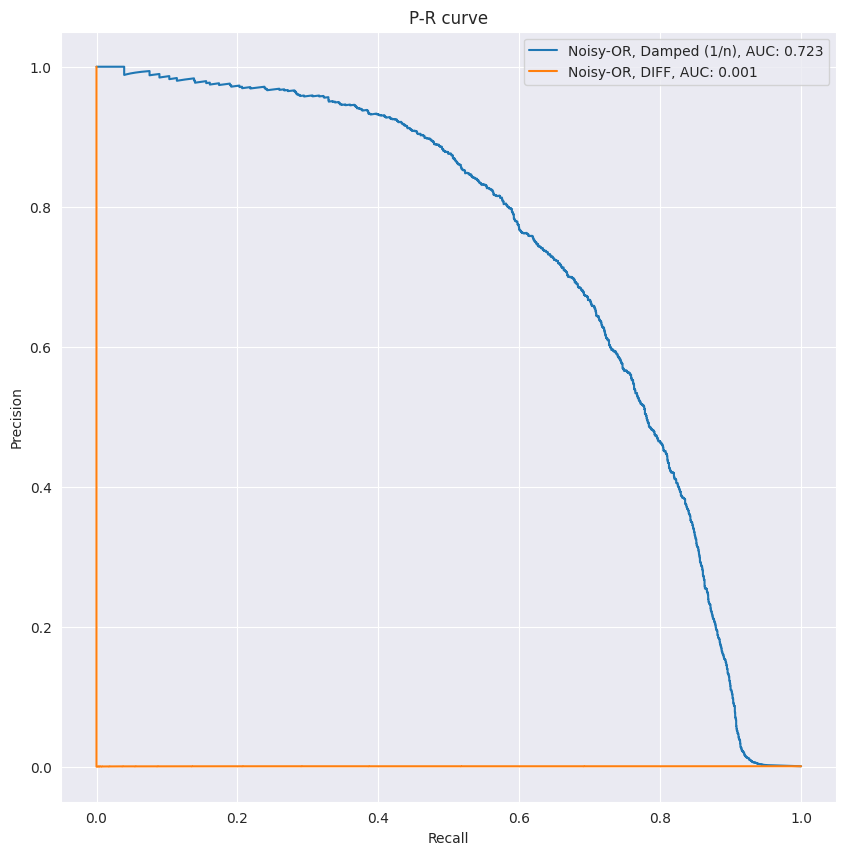

In [10]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff"] = -((selected_df["logsum_1_p_pos"] - selected_df["logsum_p_pos"]) * 2 - (selected_df["logsum_1_p_all"] - selected_df["logsum_p_all"]))

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


In [11]:
print(selected_df["pm6a_diff"].describe())

count    3.236198e+06
mean     1.115616e+03
std      3.331048e+03
min     -5.496674e+02
25%      3.768170e+02
50%      5.597520e+02
75%      1.016128e+03
max      2.452153e+05
Name: pm6a_diff, dtype: float64


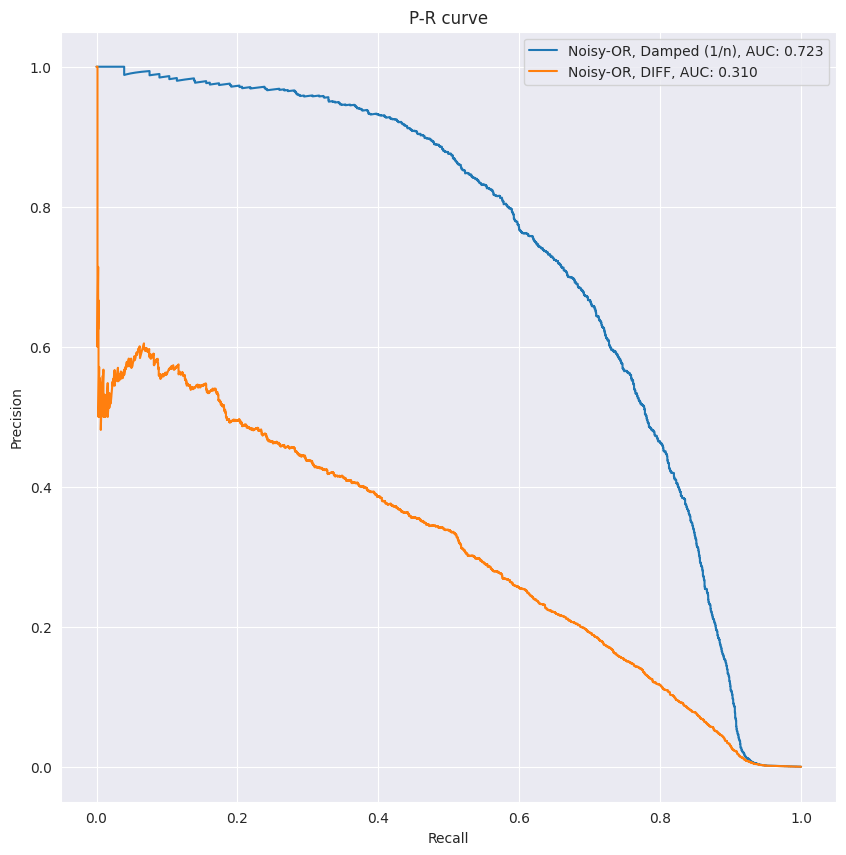

In [15]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff"] = -((selected_df["logsum_1_p_pos"] - selected_df["logsum_p_pos"]) + (selected_df["logsum_1_p_all"] - selected_df["logsum_p_all"])/selected_df["count_all"])

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


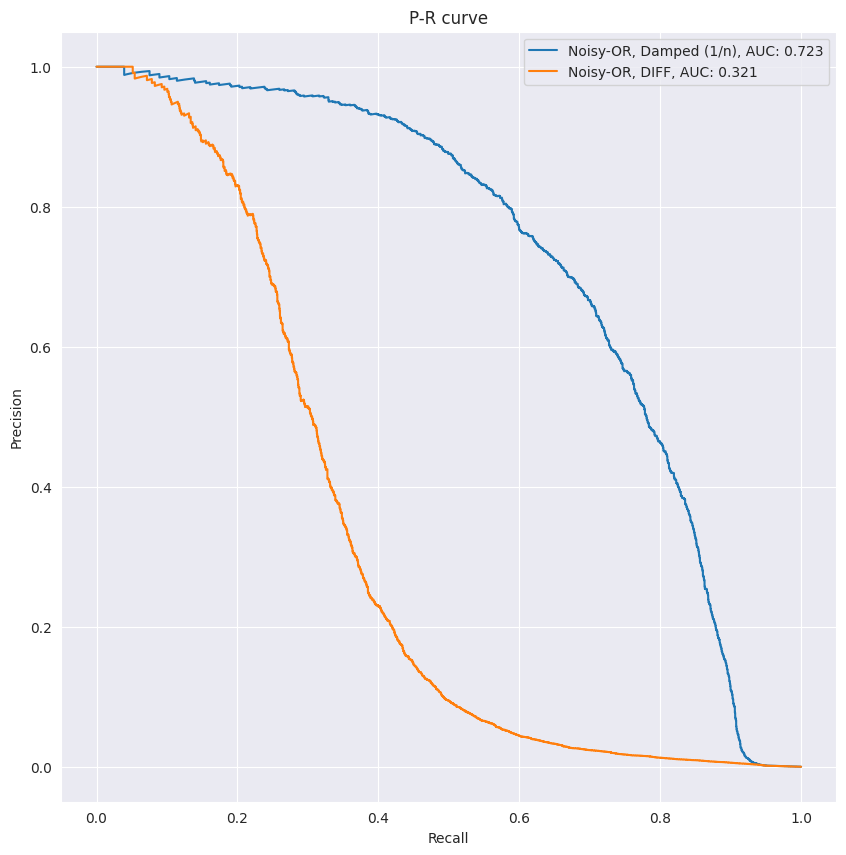

In [17]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff"] = -((selected_df["logsum_1_p_pos"] - selected_df["logsum_p_pos"])/np.clip(selected_df["count_pos"],1,None) + (selected_df["logsum_1_p_all"] - selected_df["logsum_p_all"])/selected_df["count_all"])

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


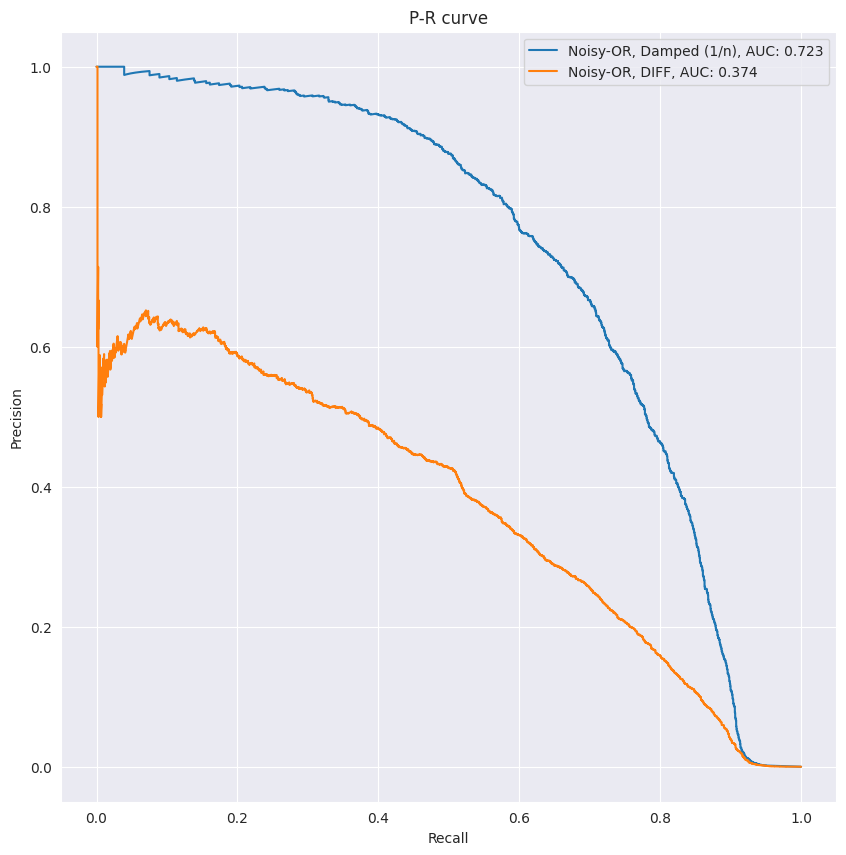

In [18]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff"] = -(selected_df["logsum_1_p_pos"] - selected_df["logsum_1_p_neg"])

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


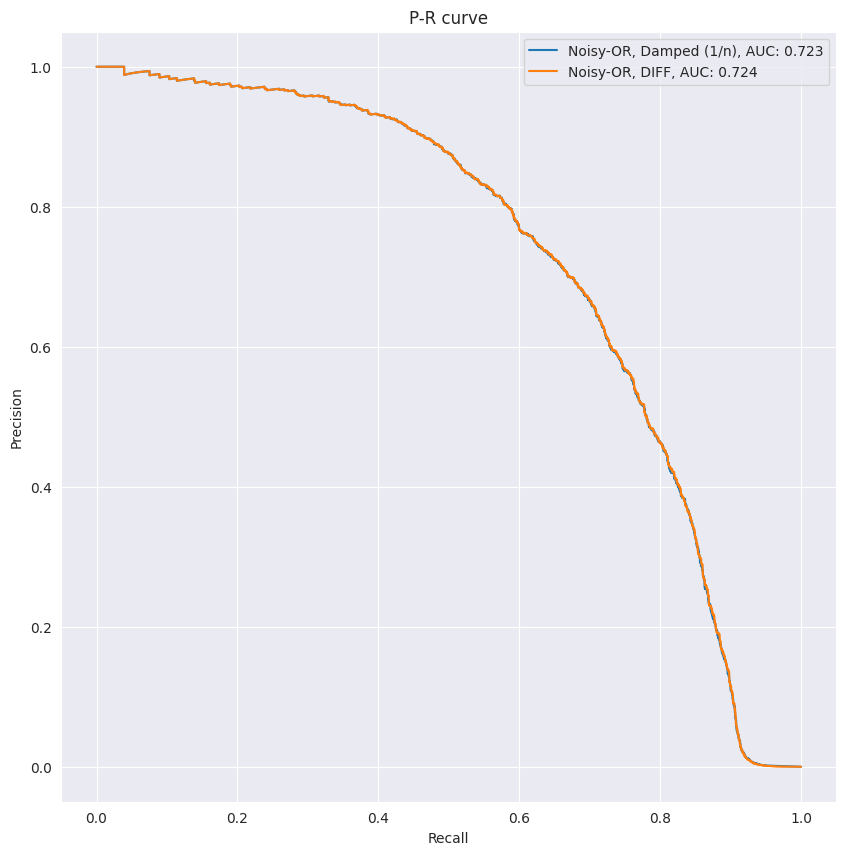

In [19]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff"] = -(selected_df["logsum_1_p_pos"] - selected_df["logsum_1_p_neg"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


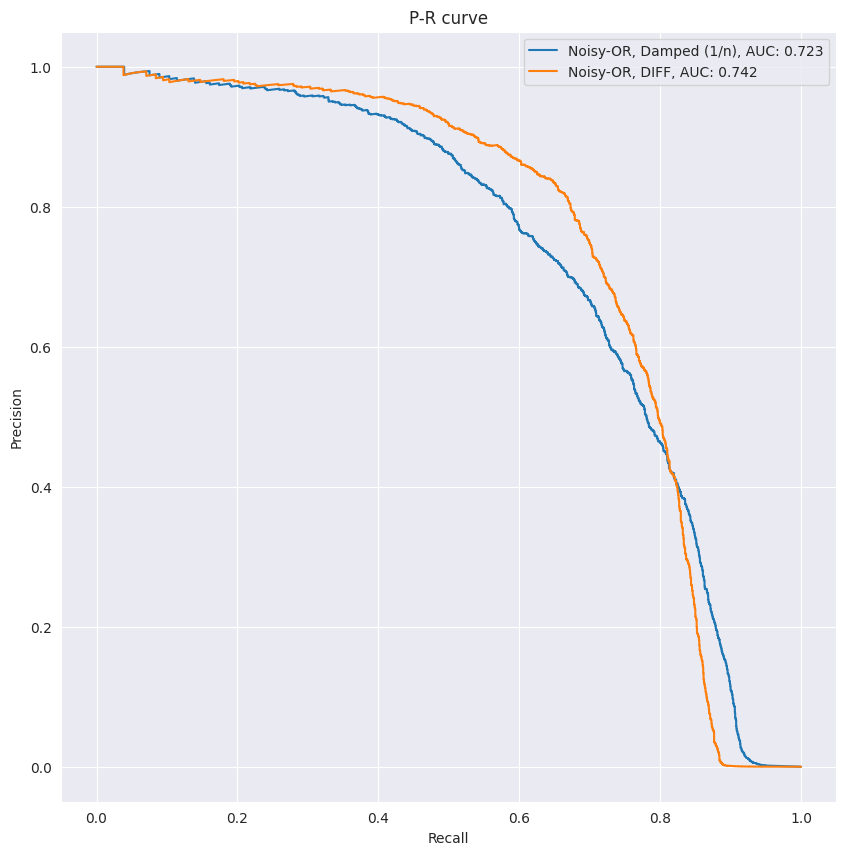

In [21]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))

selected_df["pm6a_diff"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


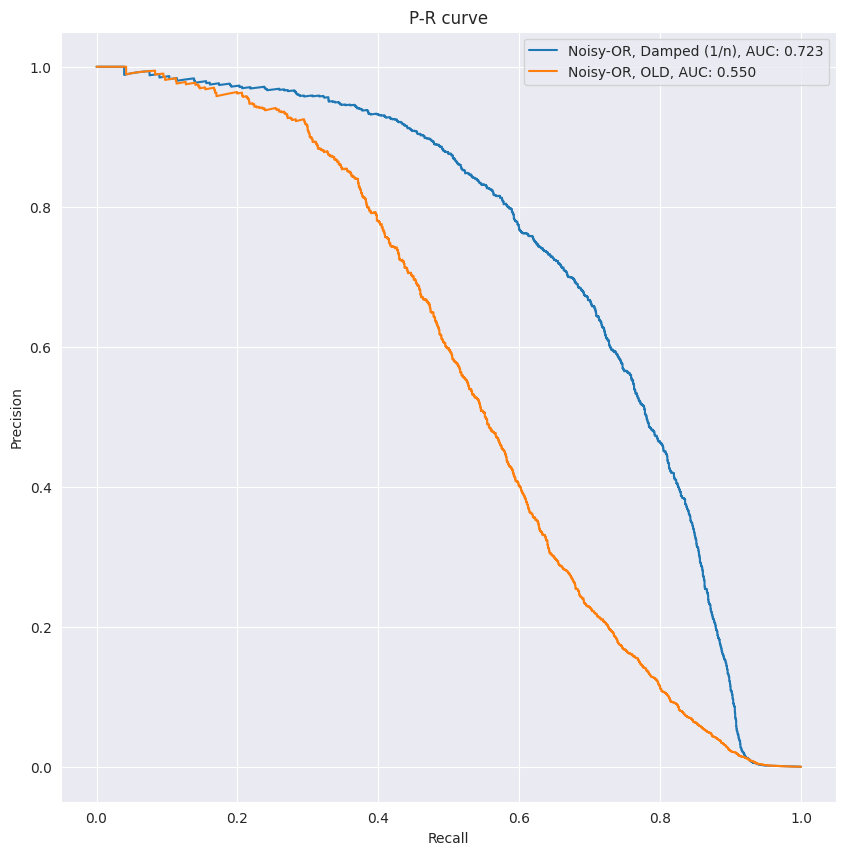

In [29]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))

selected_df["pm6a_old"] = - (selected_df["logsum_1_p_all"] / selected_df["count_all"])

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_old"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, OLD, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


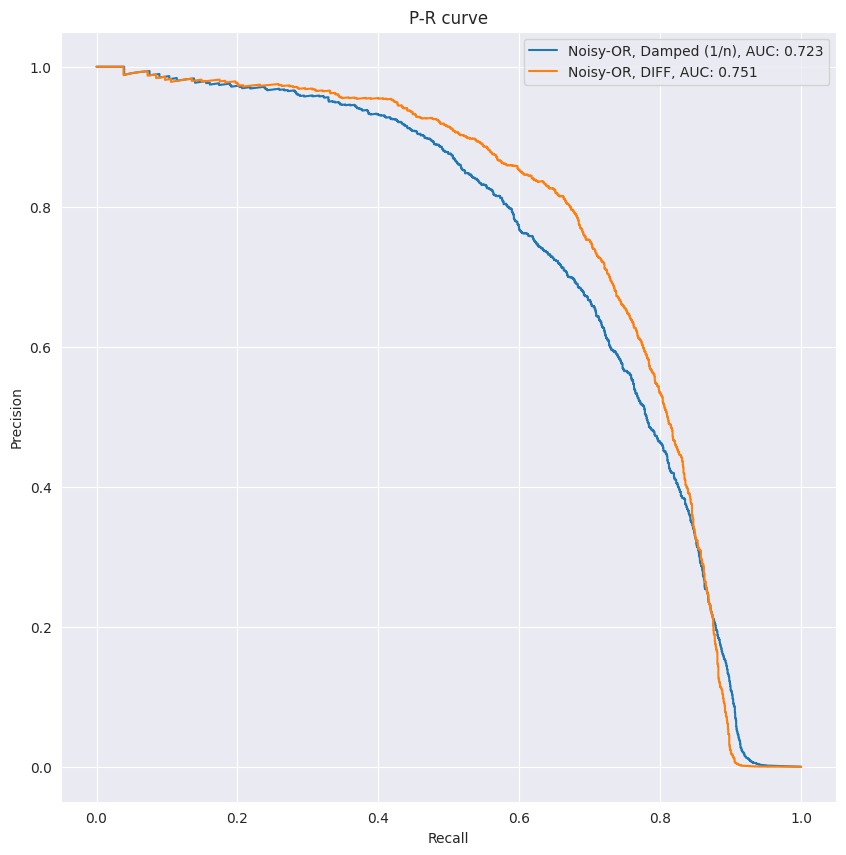

In [30]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))

selected_df["pm6a_diff"] = -(selected_df["logsum_1_p_pos"] * -np.log10(fpr) - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


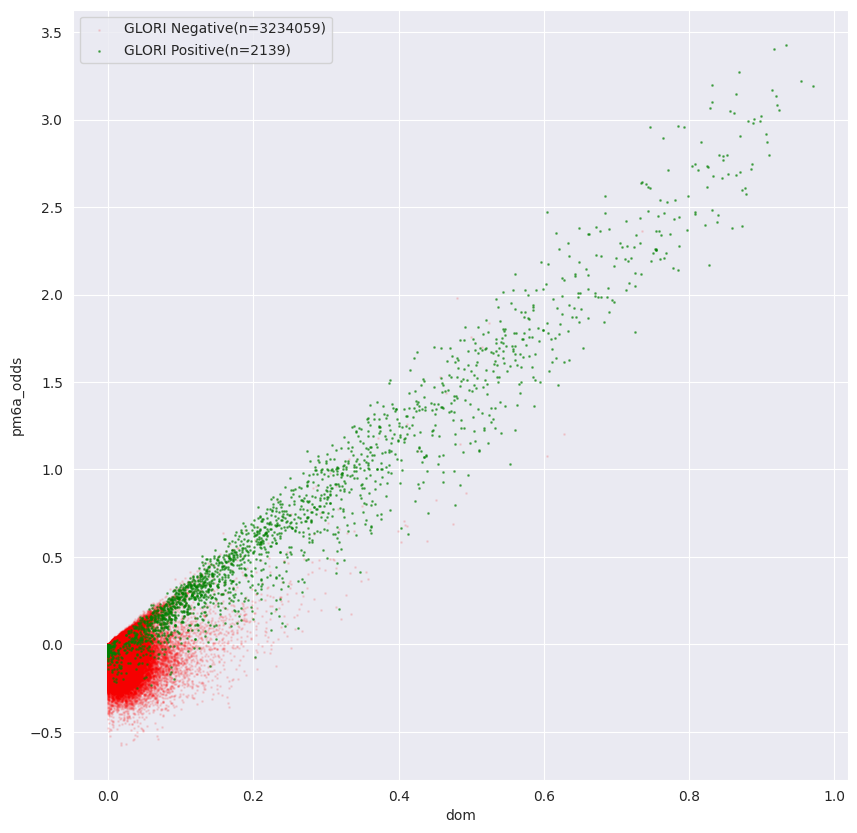

In [38]:
fpr = 0.0027
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pos"]/neg_df["count_all"], neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pos"]/pos_df["count_all"], pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")
plt.show()
plt.close()

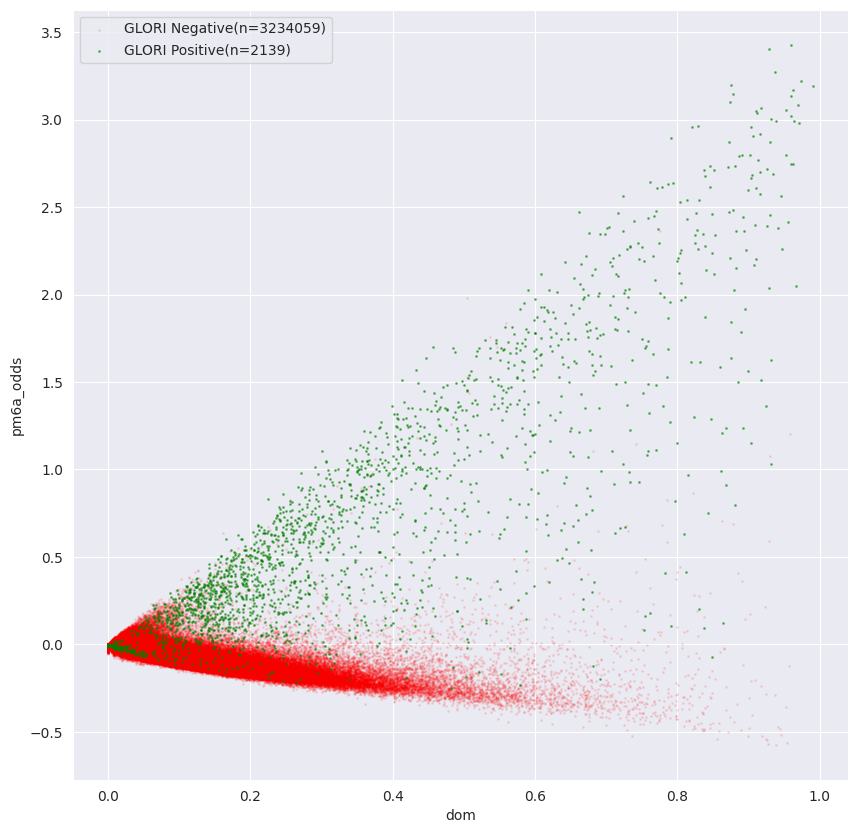

In [39]:
fpr = 0.0027
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")
plt.show()
plt.close()

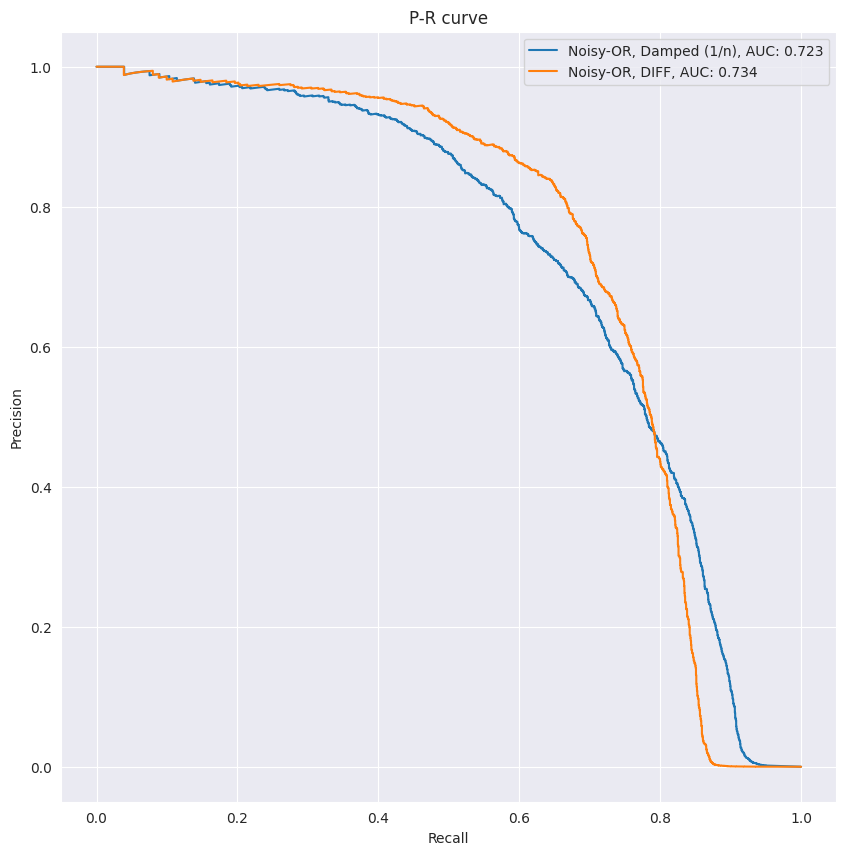

In [36]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff_dom"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


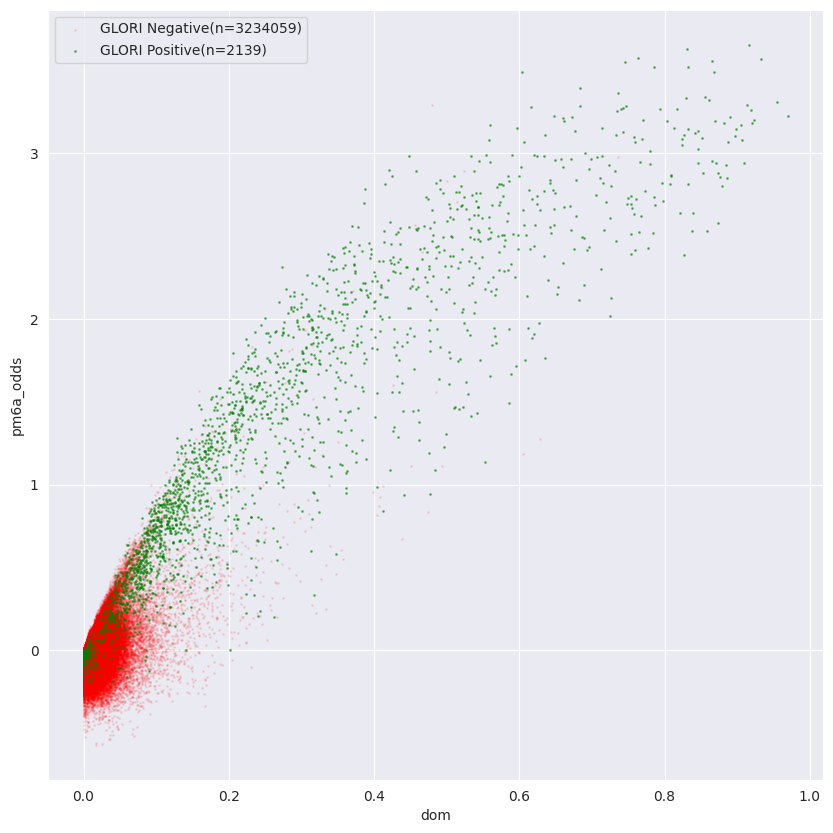

In [41]:
fpr = 0.0027
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] = -(selected_df["logsum_1_p_pos"] * 2 * (2/(1+selected_df["dom"])) - selected_df["logsum_1_p_all"])/selected_df["count_all"]
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pos"]/neg_df["count_all"], neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pos"]/pos_df["count_all"], pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")
plt.show()
plt.close()

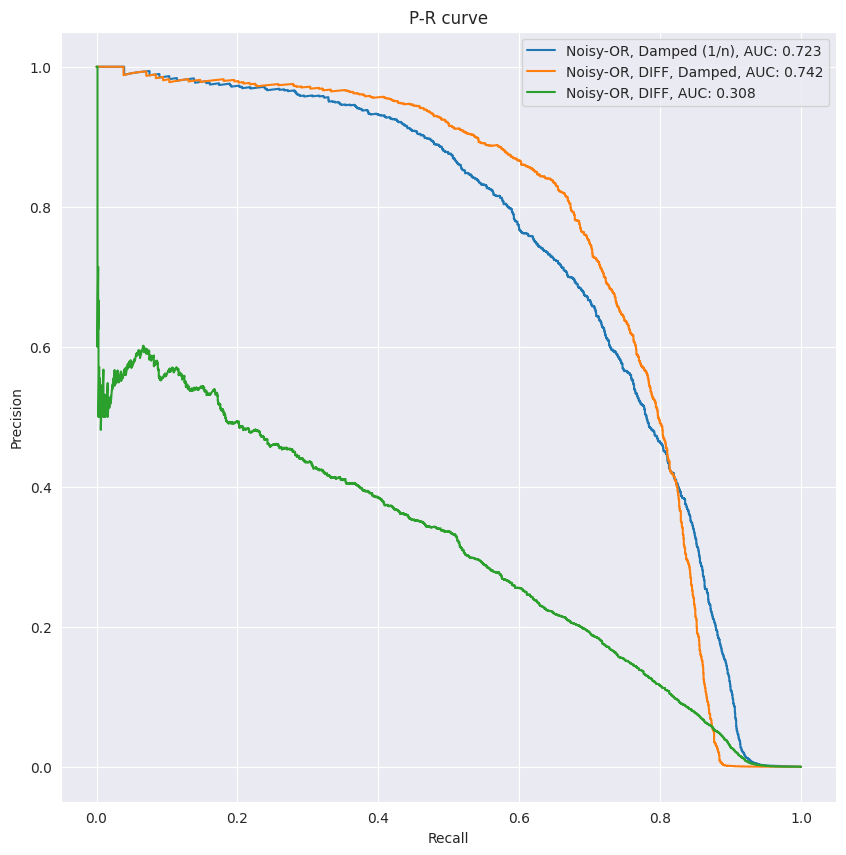

In [44]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] = -(selected_df["logsum_1_p_pos"] * 2 - (selected_df["logsum_1_p_all"]/selected_df["count_all"]))

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


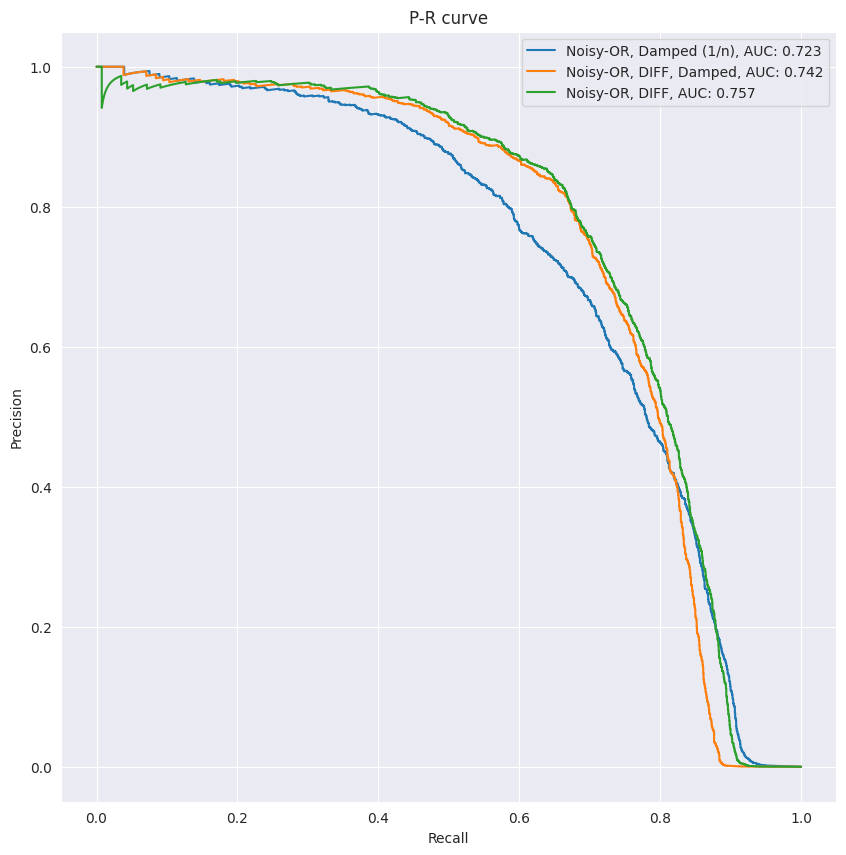

In [45]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(selected_df["logsum_1_p_pos"] * 2 * (2/(1+selected_df["dom"])) - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


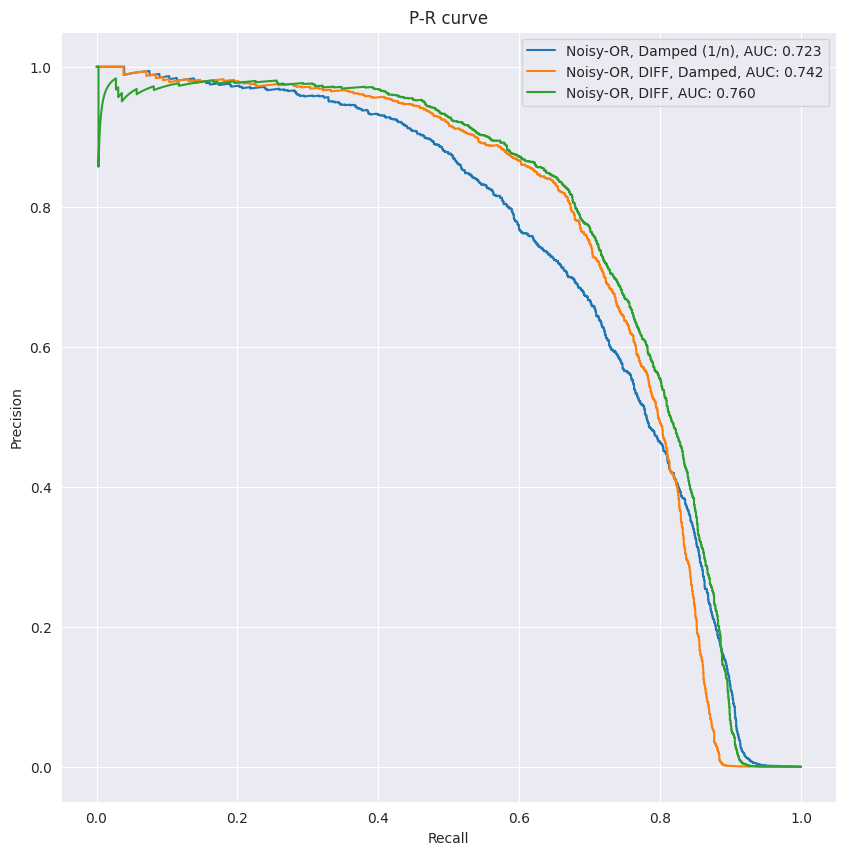

In [63]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(selected_df["logsum_1_p_pos"] * 2 * (2-selected_df["dom"]) - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


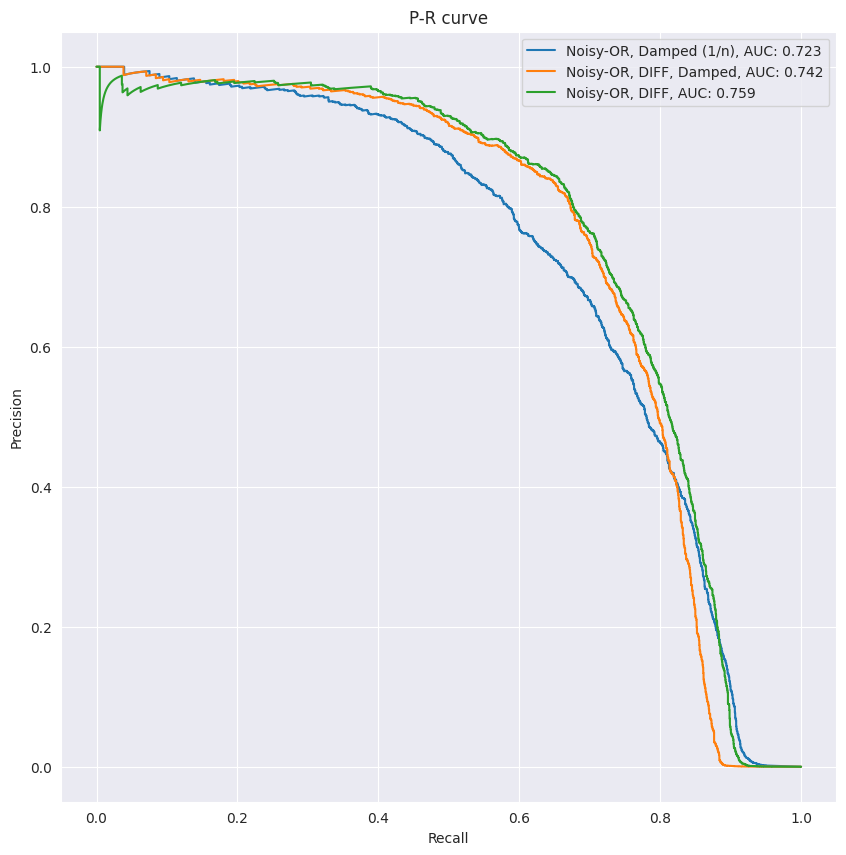

In [65]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(selected_df["logsum_1_p_pos"] * 2 * (2**(1-selected_df["dom"])) - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


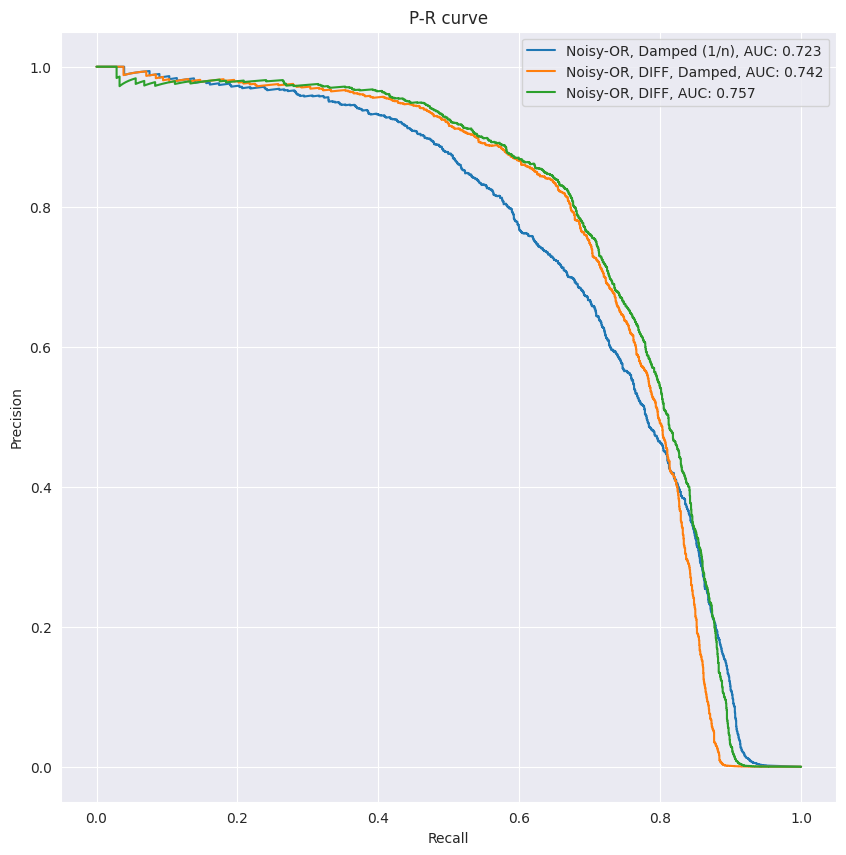

In [75]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(selected_df["logsum_1_p_pos"] * (2-selected_df["dom"]) + selected_df["logsum_1_p_pos"] - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


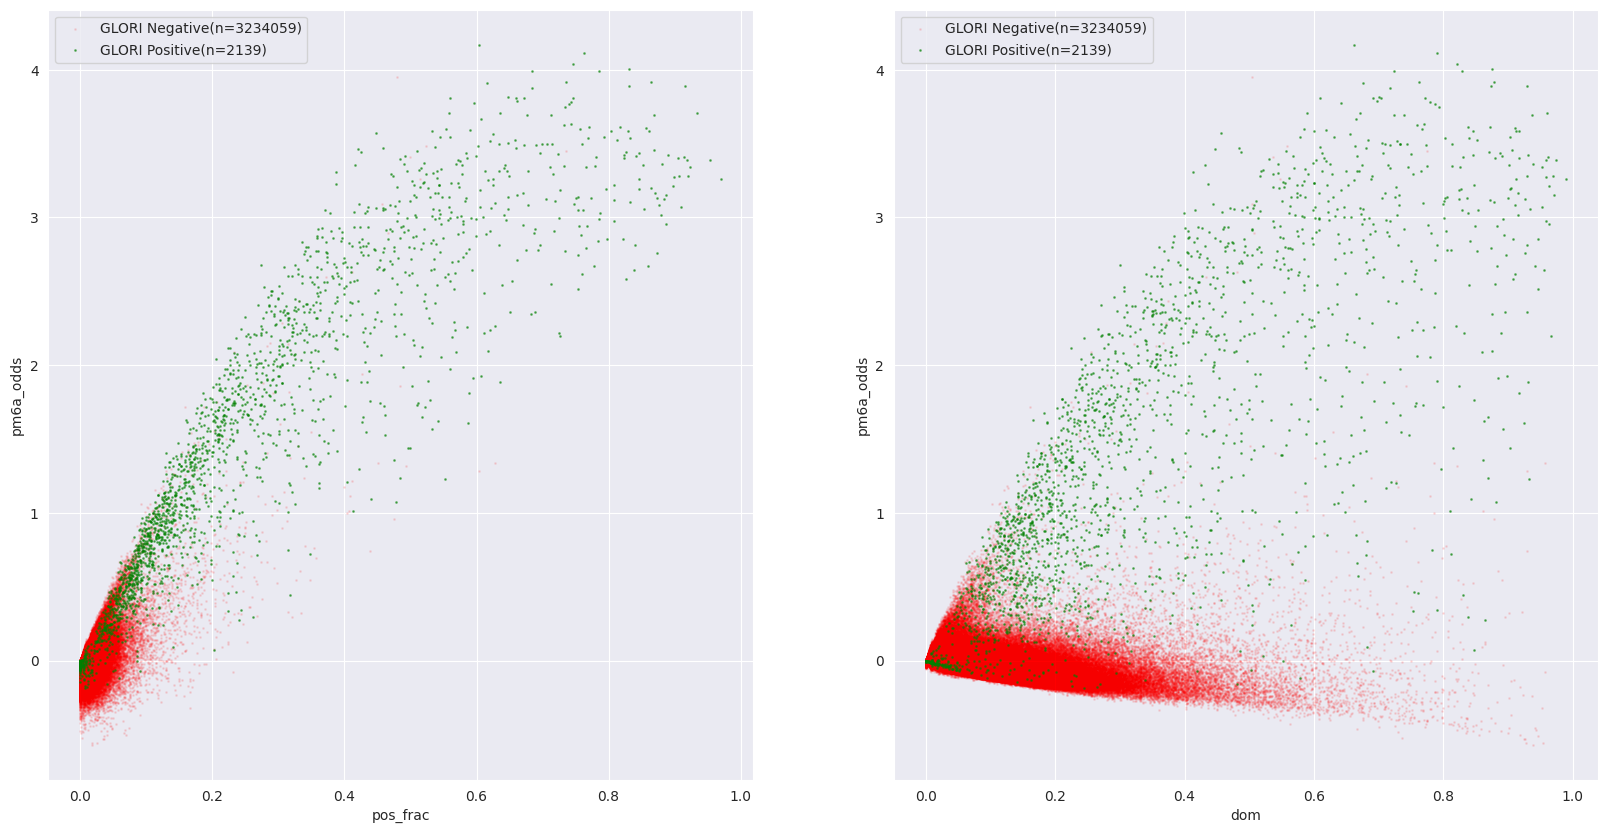

In [84]:
fpr = 0.0027
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] =  -(selected_df["logsum_1_p_pos"] * 2 * (2-selected_df["dom"]) - selected_df["logsum_1_p_all"])/selected_df["count_all"]
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

ax = axes[0]
ax.scatter(neg_df["count_pos"]/neg_df["count_all"], neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pos"]/pos_df["count_all"], pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("pos_frac")
ax.set_ylabel("pm6a_odds")

ax = axes[1]
ax.scatter(neg_df["dom"], neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")

plt.show()
plt.close()

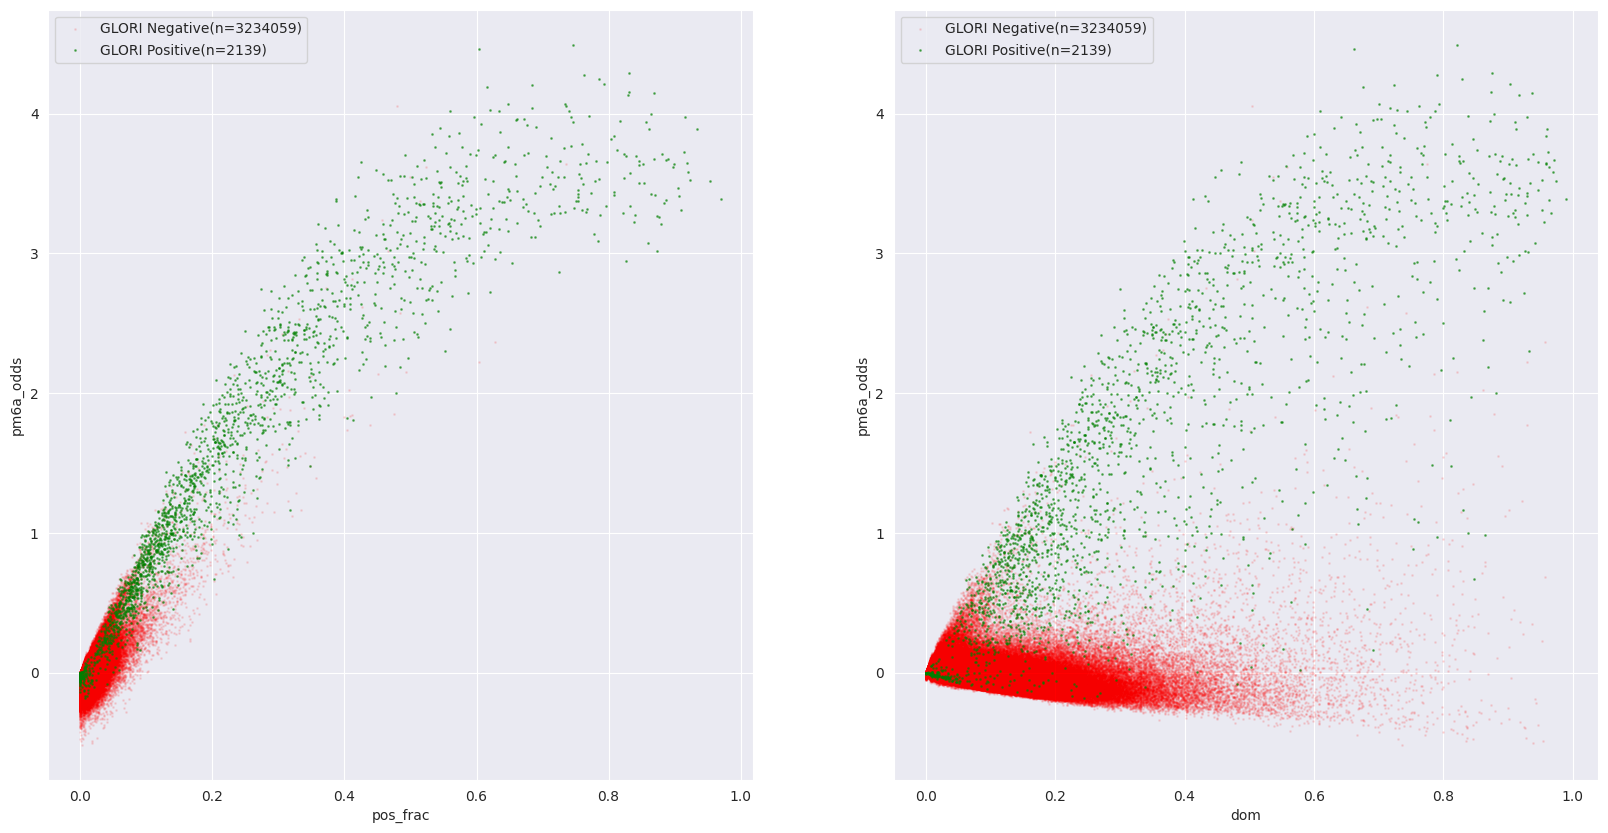

In [85]:
fpr = 0.0027
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] =  -(selected_df["logsum_1_p_pos"] * 2 * (2-(selected_df["count_pos"]/selected_df["count_all"])) - selected_df["logsum_1_p_all"])/selected_df["count_all"]
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

ax = axes[0]
ax.scatter(neg_df["count_pos"]/neg_df["count_all"], neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pos"]/pos_df["count_all"], pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("pos_frac")
ax.set_ylabel("pm6a_odds")

ax = axes[1]
ax.scatter(neg_df["dom"], neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")

plt.show()
plt.close()

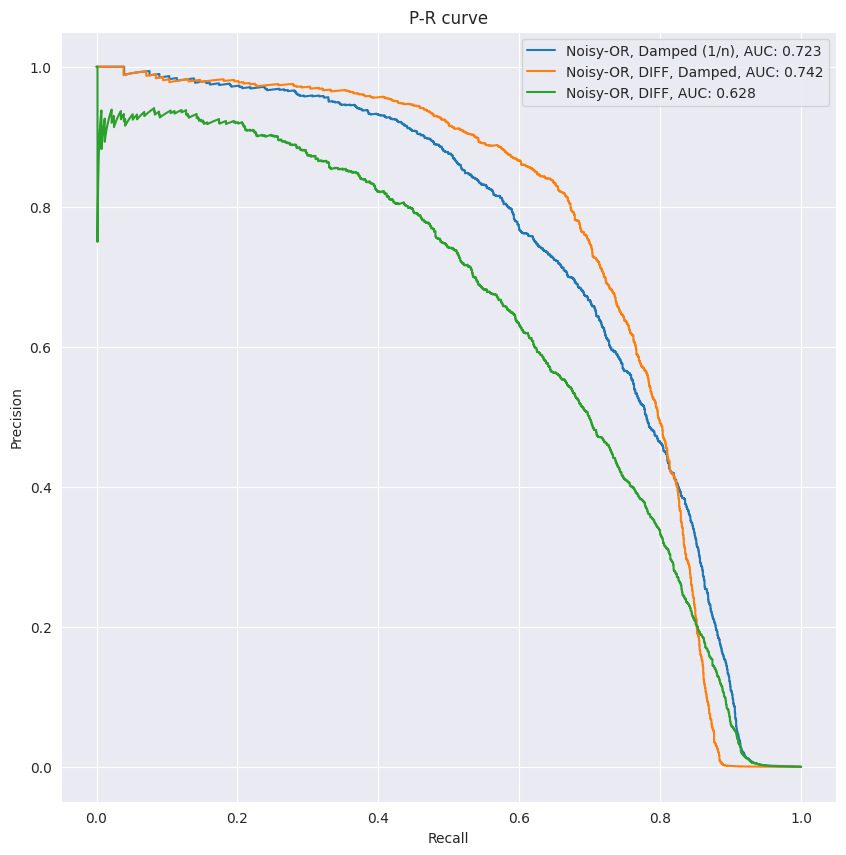

In [110]:
from scipy import stats


selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["count_pos_cdf"] = -stats.norm.logsf(selected_df["count_pos"] - 0.5, selected_df["count_all"] * fpr, np.sqrt(selected_df["count_all"] * fpr * (1-fpr)))

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["count_pos_cdf"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()

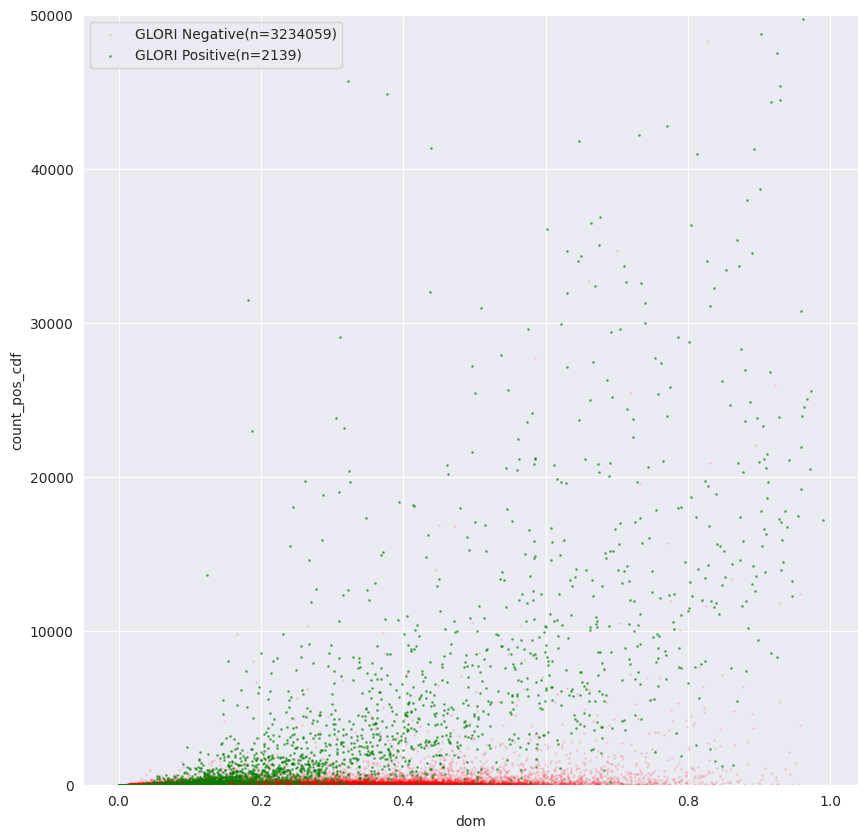

In [116]:
fpr = 0.0027
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["count_pos_cdf"] = -stats.norm.logsf(selected_df["count_pos"] - 0.5, selected_df["count_all"] * fpr, np.sqrt(selected_df["count_all"] * fpr * (1-fpr)))

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["count_pos_cdf"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["count_pos_cdf"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("count_pos_cdf")
ax.set_ylim(0,50000)
plt.show()
plt.close()

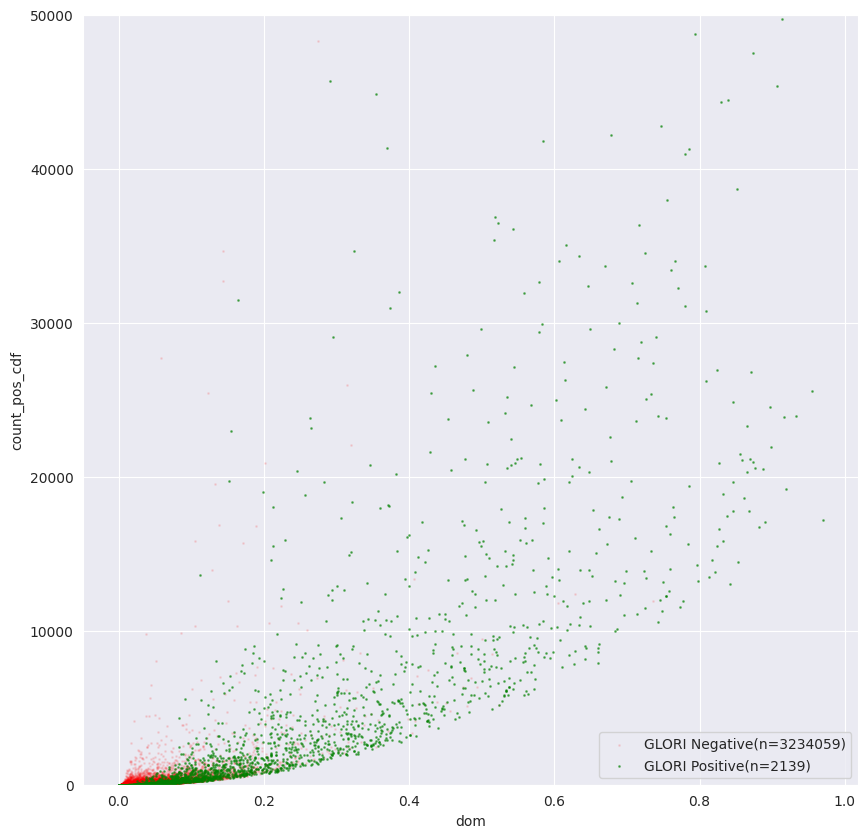

In [117]:
fpr = 0.0027
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["count_pos_cdf"] = -stats.norm.logsf(selected_df["count_pos"] - 0.5, selected_df["count_all"] * fpr, np.sqrt(selected_df["count_all"] * fpr * (1-fpr)))

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pos"] / neg_df["count_all"] , neg_df["count_pos_cdf"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pos"] / pos_df["count_all"] , pos_df["count_pos_cdf"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("count_pos_cdf")
ax.set_ylim(0,50000)
plt.show()
plt.close()

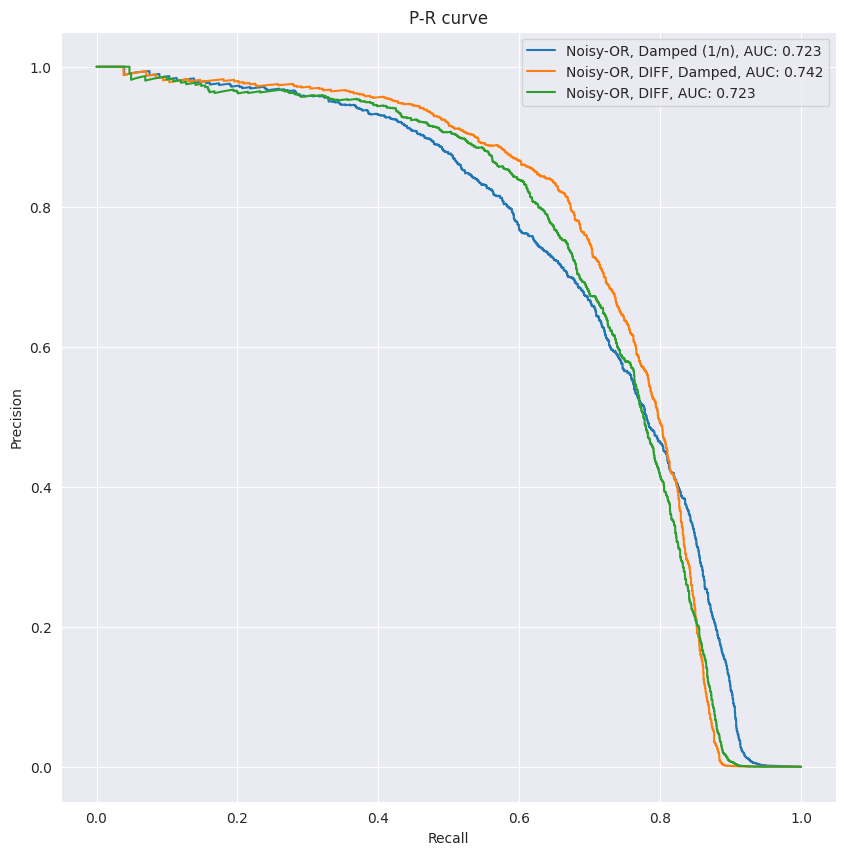

In [124]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(selected_df["logsum_1_p_pos"] * 4 * (1-np.sqrt(selected_df["dom"]*(1-selected_df["dom"]))) - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


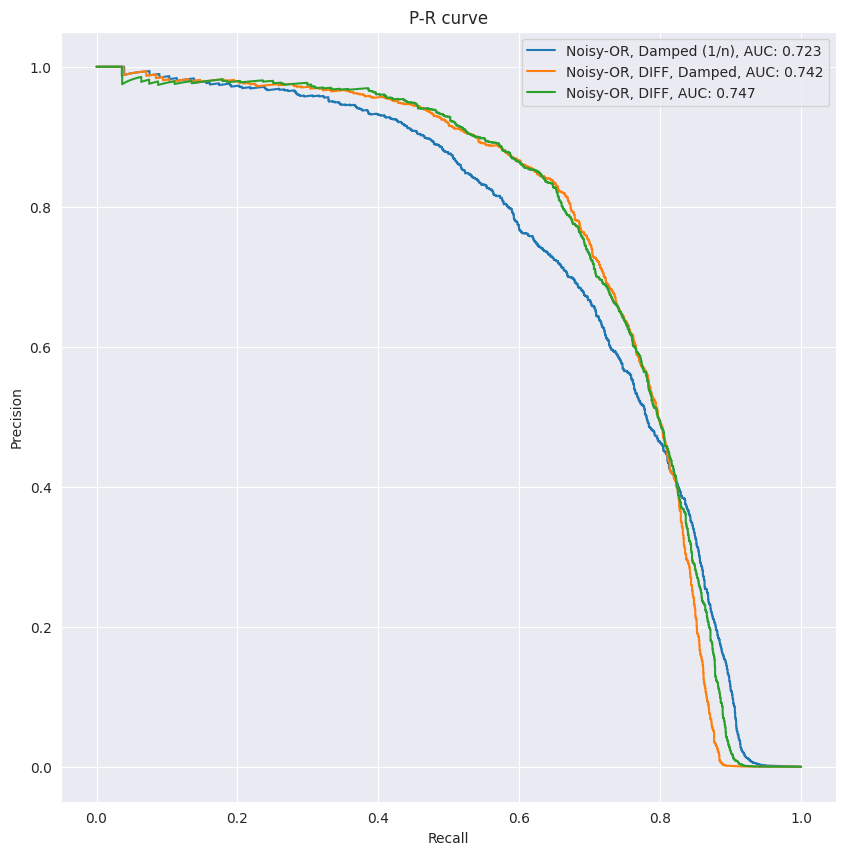

In [126]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(selected_df["logsum_1_p_pos"] * 2 * (2-np.sqrt(selected_df["dom"]*(2-selected_df["dom"]))) - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


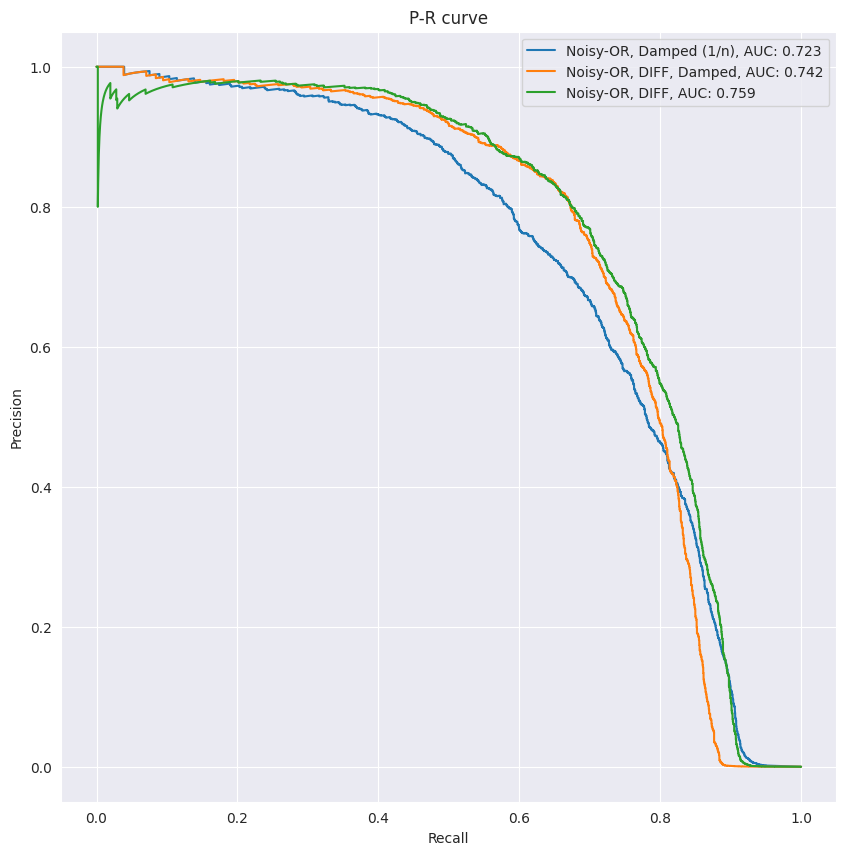

In [131]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(selected_df["logsum_1_p_pos"] * 2 * (2-selected_df["dom"]**2) - selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


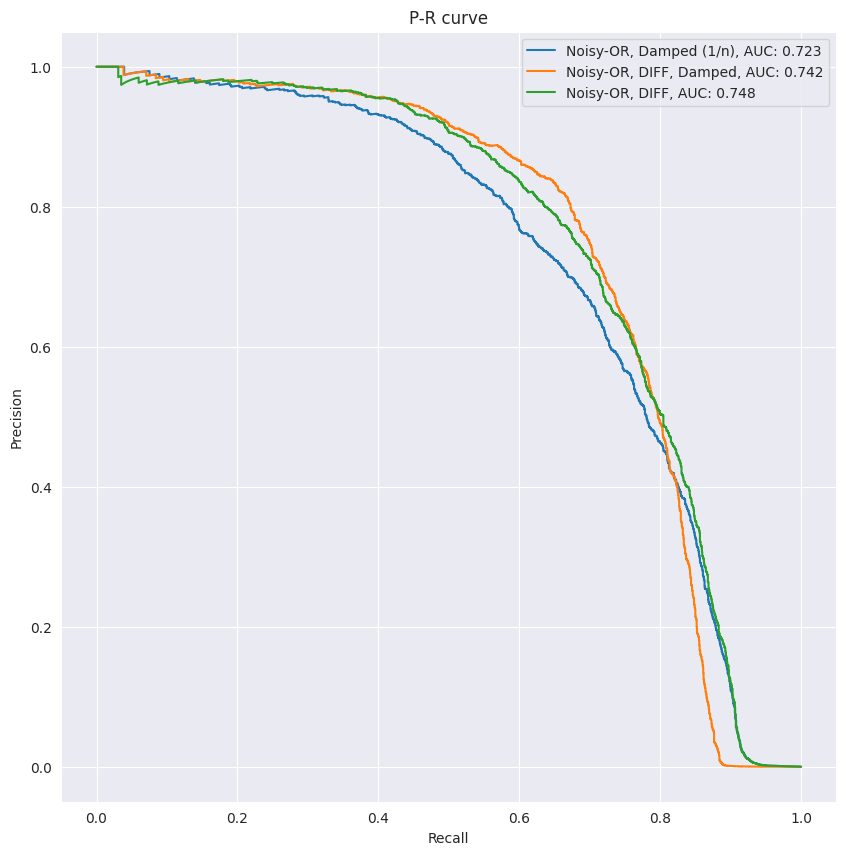

In [134]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


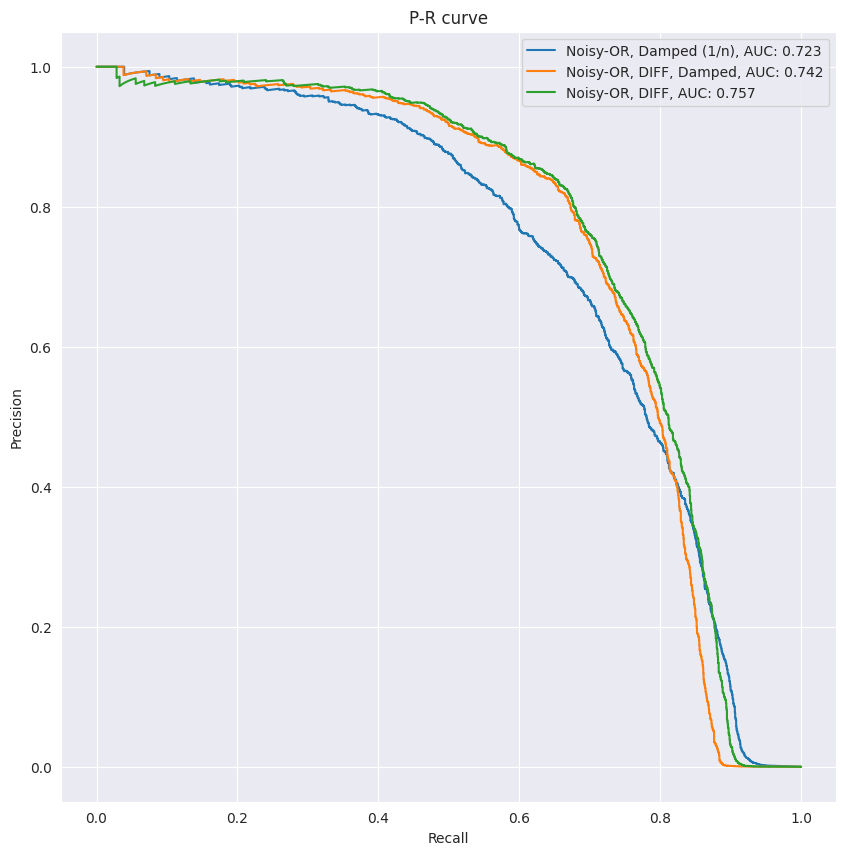

In [142]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -((3-selected_df["dom"])*selected_df["logsum_1_p_pos"]-selected_df["logsum_1_p_all"])/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


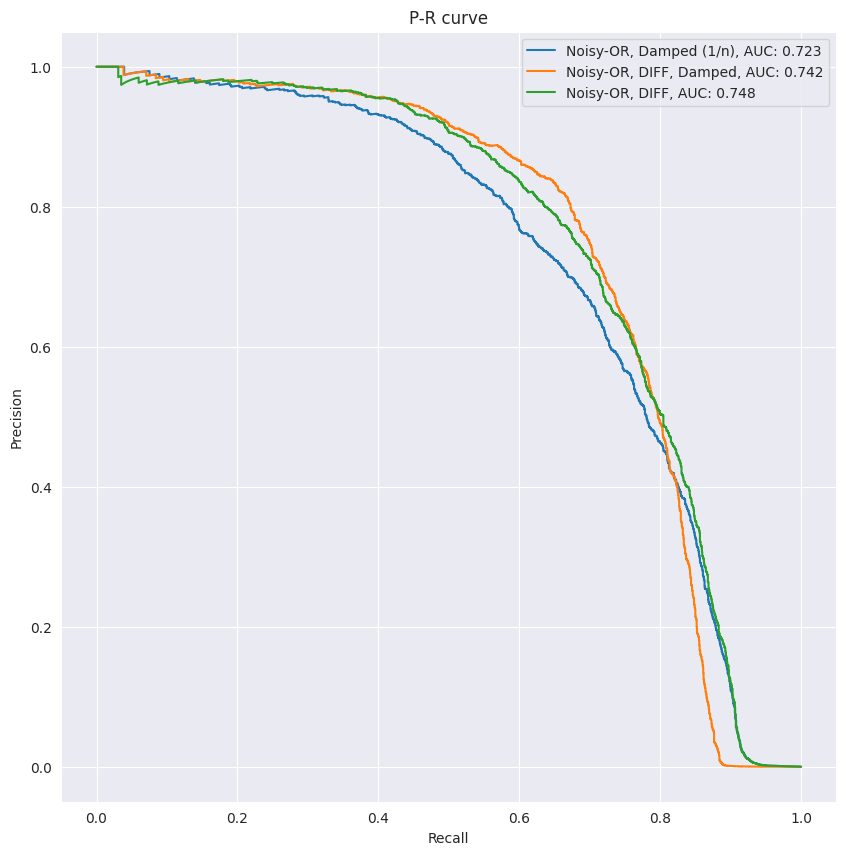

In [146]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


In [144]:
logsum_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(logsum_df, allow_pickle=True) as data:
    logsum_df = pd.DataFrame({key: data[key] for key in data.keys()})
logsum_df = logsum_df[logsum_df["count_dom"] >= 20]
logsum_df = logsum_df.merge(label_df_filtered, on="label_id", how="inner")
print(logsum_df)

                label_id     p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000  0.606511      0.000000        0.000000          0   
1         NM_000016:1008  0.948786      0.000000        0.000000          0   
2         NM_000016:1009  2.607620      0.000000        0.000000          0   
3         NM_000016:1010  4.912612      0.000000        0.000000          0   
4         NM_000016:1014  3.237954      0.000000        0.000000          0   
...                  ...       ...           ...             ...        ...   
10794116  NR_182669:3964  1.226287      0.000000        0.000000          0   
10794117  NR_182669:3965  1.268912      0.000000        0.000000          0   
10794118  NR_182669:3966  1.295230      0.000000        0.000000          0   
10794119  NR_182669:3968  2.394934     -0.006871       -1.804221          1   
10794120  NR_182669:3969  1.723521      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg  count_neg  

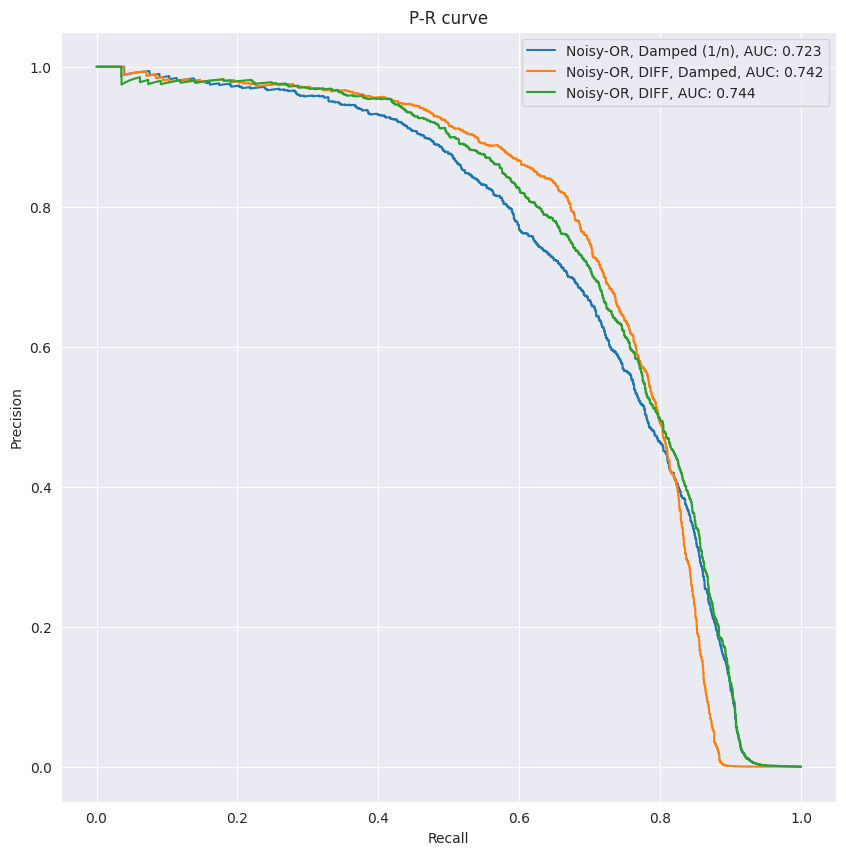

In [145]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(2-selected_df["p_sum"]/selected_df["count_all"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()


In [ ]:
fpr = 0.0027

selected_df = logsum_df[(logsum_df["drach"]) & (logsum_df["count_dom"] >= 20) & (logsum_df["label"] >= 0)]
selected_df = selected_df[selected_df["label"] >=0]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_diff_damp"] = -(selected_df["logsum_1_p_pos"] * 2 - selected_df["logsum_1_p_all"])/selected_df["count_all"]
selected_df["pm6a_diff"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, DIFF, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
